## Attempting to compare exfor endf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor

# --- CONFIGURATION ---
TARGET_ISO = "Am241"   # Am-241 is a classic HPRL target
TARGET_MT = 18         # 18 = (n,f), 102 = (n,gamma)
CUTOFF_EV = 1e5        # 100 keV (Fast region start)
LIBRARY = "endfb8.0"   # The "Base" model we are correcting

print("Libraries loaded. Configuration set.")

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded. Configuration set.


In [2]:
print(f"Loading reference evaluation for {TARGET_ISO} MT={TARGET_MT}...")

# Load ENDF data (The smooth curve)
df_eval = nuc_data.load_evaluation(TARGET_ISO, TARGET_MT, library=LIBRARY)

# Filter for Fast Region
df_eval = df_eval[df_eval['Energy'] > CUTOFF_EV].copy()

# Log Transform (Physics standard)
df_eval['Log_Energy'] = np.log10(df_eval['Energy'])
df_eval['Log_XS_Eval'] = np.log10(df_eval['Data'])

print(f"Reference Loaded: {len(df_eval)} points from {LIBRARY}")
df_eval.head()

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.


Loading reference evaluation for Am241 MT=18...
Reference Loaded: 0 points from endfb8.0


,Energy,Data,Log_Energy,Log_XS_Eval


In [5]:
import os

print("Searching for EXFOR files...")

# Strategy: Walk through the current directory and subdirectories
# If you know the data is in a specific folder (like 'C:/NucML_Data'), change '.' to that path.
search_root = '.' 

found_files = []
for root, dirs, files in os.walk(search_root):
    for file in files:
        # Looking for typical NucML EXFOR filenames
        # They often look like 'EXFOR_n_f.csv' or '95241.csv' or 'Am241.csv'
        if file.endswith(".csv") and ("EXFOR" in file or "Am" in file or "95241" in file):
            full_path = os.path.join(root, file)
            found_files.append(full_path)

if found_files:
    print(f"Found {len(found_files)} potential files. Top 3 candidates:")
    for f in found_files[:3]:
        print(f" - {f}")
else:
    print("No obvious CSV files found in the current directory tree.")
    print("Please manually copy the absolute path of the file you saw earlier.")

Searching for EXFOR files...
Found 23 potential files. Top 3 candidates:
 - ./NucMLClone2/EXFOR/CSV_Files/EXFOR_deuterons/EXFOR_deuterons_ORIGINAL.csv
 - ./NucMLClone2/EXFOR/CSV_Files/EXFOR_deuterons/EXFOR_deuterons_ORIGINAL_w_AME.csv
 - ./NucMLClone2/EXFOR/CSV_Files/EXFOR_deuterons/EXFOR_deuterons_MF3_AME_no_RawNaN.csv


In [6]:
import os

# We know the EXFOR folder exists here based on your previous output
base_exfor_path = "./NucMLClone2/EXFOR/CSV_Files/"

print(f"Checking contents of {base_exfor_path} ...")

try:
    # List folders to confirm 'EXFOR_neutrons' exists
    subfolders = os.listdir(base_exfor_path)
    print("Folders found:", subfolders)
    
    # Construct the probable path to the neutron data
    neutron_path = os.path.join(base_exfor_path, "EXFOR_neutrons")
    
    if os.path.exists(neutron_path):
        print(f"\n--- Searching inside {neutron_path} ---")
        files = os.listdir(neutron_path)
        # Look for the main cleaned CSV
        candidates = [f for f in files if "neutrons" in f and ".csv" in f]
        for c in candidates:
            print(f" -> {c}")
    else:
        print("\nWARNING: 'EXFOR_neutrons' folder not found. You might need to compile/download it.")

except Exception as e:
    print(f"Error checking path: {e}")

Checking contents of ./NucMLClone2/EXFOR/CSV_Files/ ...
Folders found: ['EXFOR_deuterons', 'EXFOR_helions', 'EXFOR_neutrons', 'README.md', 'EXFOR_protons', 'EXFOR_gammas', 'EXFOR_alphas']

--- Searching inside ./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons ---
 -> EXFOR_neutrons_MF3_AME_no_RawNaN.csv
 -> EXFOR_neutrons_ORIGINAL.csv
 -> EXFOR_neutrons_ORIGINAL_w_AME.csv


## attempt 2

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc # Garbage Collection for memory management
from autogluon.tabular import TabularPredictor

# --- CONFIGURATION ---
TARGET_ISO = "Am241"
TARGET_MT = 18          # Fission
CUTOFF_EV = 1e5         # 100 keV (Fast Region)

# --- YOUR PATHS (Updated based on our findings) ---
# 1. The Theory (ENDF/B-VIII.0)
PATH_EVAL = "/Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/mt18.csv"

# 2. The Experiments (EXFOR)
PATH_EXFOR = "./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"

print("Configuration loaded. Ready to build the pipeline.")

Configuration loaded. Ready to build the pipeline.


In [34]:
import os
import pandas as pd
import numpy as np

# 1. Setup
DIR_PATH = "/Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs"
TARGET_FILE = "n-Am241-MT018-G171.endfb8.0"
FULL_PATH = os.path.join(DIR_PATH, TARGET_FILE)

print(f"Loading: {TARGET_FILE}")

try:
    # 2. Load all columns first to inspect structure
    # The file appears to have 4 columns based on your output
    df_eval = pd.read_csv(FULL_PATH, sep='\s+', comment='#', header=None)
    
    # Take only the first two columns (Energy and Sigma)
    df_eval = df_eval.iloc[:, :2].copy()
    df_eval.columns = ['energy', 'sigma']
    
    # 3. UNIT DETECTION (The Fix)
    max_energy = df_eval['energy'].max()
    print(f"Max Energy found in file: {max_energy}")
    
    if max_energy < 50:
        print("--> DETECTED UNITS: MeV (Mega-electron Volts)")
        # Convert MeV to eV so it matches EXFOR (which is usually eV)
        # 1 MeV = 1,000,000 eV
        df_eval['energy'] = df_eval['energy'] * 1e6
        print("--> Converted Energy to eV.")
    else:
        print("--> DETECTED UNITS: eV (electron Volts)")

    # 4. Filter Fast Region
    # Now that units are definitely eV, we can use 1e5 safely
    CUTOFF_EV = 1e5
    df_eval = df_eval[df_eval['energy'] > CUTOFF_EV].copy()
    
    if len(df_eval) == 0:
        print("WARNING: Dataframe still empty. Check the cutoff logic.")
    else:
        # 5. Log Transform
        df_eval['log_e'] = np.log10(df_eval['energy'])
        df_eval['log_xs_eval'] = np.log10(df_eval['sigma'])

        print(f"SUCCESS: Evaluation loaded with {len(df_eval)} fast region points.")
        print(df_eval.head())

except Exception as e:
    print(f"CRITICAL ERROR: {e}")

Loading: n-Am241-MT018-G171.endfb8.0
Max Energy found in file: 16.487
--> DETECTED UNITS: MeV (Mega-electron Volts)
--> Converted Energy to eV.
SUCCESS: Evaluation loaded with 101 fast region points.
      energy    sigma     log_e  log_xs_eval
70  111090.0  15.7039  5.045675     1.196008
71  116790.0  15.8267  5.067406     1.199390
72  122770.0  16.2031  5.089092     1.209598
73  129070.0  16.7586  5.110825     1.224238
74  135690.0  17.3209  5.132548     1.238570


In [35]:
import pandas as pd

# Path to the massive file
PATH_EXFOR = "./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"

print(f"Peeking at headers in: {PATH_EXFOR}")

# Read only 5 rows to see the column names
df_peek = pd.read_csv(PATH_EXFOR, nrows=5)

print("\n--- EXACT COLUMN NAMES ---")
print(list(df_peek.columns))

Peeking at headers in: ./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv

--- EXACT COLUMN NAMES ---
['Projectile', 'Target_Metastable_State', 'MT', 'Product_Metastable_State', 'EXFOR_Status', 'Center_of_Mass_Flag', 'Energy', 'dEnergy', 'Data', 'dData', 'ELV/HL', 'dELV/HL', 'I78', 'Short_Reference', 'EXFOR_Accession_Number', 'EXFOR_SubAccession_Number', 'EXFOR_Pointer', 'Z', 'Reaction_Notation', 'Title', 'Year', 'Author', 'Institute', 'Date', 'Reference', 'Dataset_Number', 'EXFOR_Entry', 'Reference_Code', 'Projectile_Z', 'Projectile_A', 'Projectile_N', 'Isotope', 'Element', 'N', 'A', 'Element_Flag', 'Nucleus_Radius', 'Neutron_Nucleus_Radius_Ratio', 'O', 'Mass_Excess', 'dMass_Excess', 'Binding_Energy', 'dBinding_Energy', 'B_Decay_Energy', 'dB_Decay_Energy', 'Atomic_Mass_Micro', 'dAtomic_Mass_Micro', 'S(2n)', 'dS(2n)', 'S(2p)', 'dS(2p)', 'Q(a)', 'dQ(a)', 'Q(2B-)', 'dQ(2B-)', 'Q(ep)', 'dQ(ep)', 'Q(B-n)', 'dQ(B-n)', 'S(n)', 'dS(n)', 'S(p)', 'dS(p)', 'Q(4B-)'

In [36]:

import pandas as pd
import numpy as np
import gc

# 1. Configuration
PATH_EXFOR = "./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"
CUTOFF_EV = 1e5

print(f"Loading Truth (EXFOR) from: {PATH_EXFOR}")
print("Reading massive file... (Wait 30-60s)")

try:
    # 2. Read CSV (Low memory mode false)
    df_all = pd.read_csv(PATH_EXFOR, low_memory=False)

    # 3. Filter IMMEDIATELY for Am-241 (Z=95, A=241, MT=18)
    # Using specific column names you found: 'Z', 'A', 'MT'
    df_exp = df_all[
        (df_all['Z'] == 95) & 
        (df_all['A'] == 241) & 
        (df_all['MT'] == 18)
    ].copy()

    # Clean Memory
    del df_all
    gc.collect()

    # 4. Standardize Columns (The Fix)
    # We rename 'Energy' -> 'energy' and 'Data' -> 'sigma'
    # This matches the df_eval format we created in Cell 2
    rename_map = {'Energy': 'energy', 'Data': 'sigma'}
    df_exp.rename(columns=rename_map, inplace=True)

    # 5. Filter Fast Region
    df_exp = df_exp[df_exp['energy'] > CUTOFF_EV].copy()
    
    # Remove non-physical zeros/negatives
    df_exp = df_exp[df_exp['sigma'] > 0].copy()

    # 6. Log Transform
    df_exp['log_e'] = np.log10(df_exp['energy'])
    df_exp['log_xs_exp'] = np.log10(df_exp['sigma'])

    print(f"SUCCESS: Loaded {len(df_exp)} experimental points.")
    print(df_exp[['energy', 'sigma', 'log_e', 'log_xs_exp']].head())

except Exception as e:
    print(f"CRITICAL ERROR: {e}")

Loading Truth (EXFOR) from: ./NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
Reading massive file... (Wait 30-60s)
SUCCESS: Loaded 609 experimental points.
           energy  sigma     log_e  log_xs_exp
4252274  120000.0  0.020  5.079181   -1.698970
4252275  140000.0  0.022  5.146128   -1.657577
4252276  160000.0  0.024  5.204120   -1.619789
4252277  180000.0  0.027  5.255273   -1.568636
4252278  200000.0  0.030  5.301030   -1.522879


--- Checking for Unit Mismatch ---
Average Evaluation Value: 1.2687
Average Experiment Value: 1.1355
--> Units appear aligned (Barns).


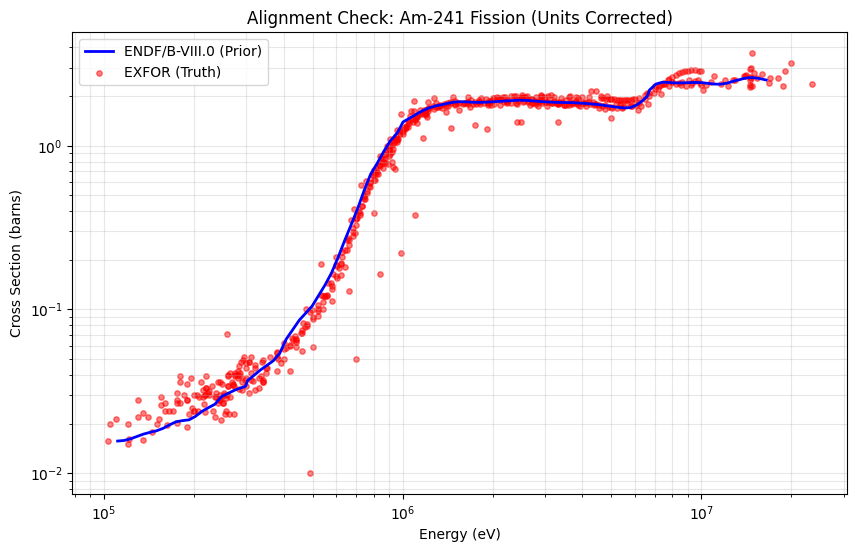

In [39]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Checking for Unit Mismatch ---")

# Calculate averages to detect the scale difference
avg_eval = df_eval['sigma'].mean()
avg_exp = df_exp['sigma'].mean()

print(f"Average Evaluation Value: {avg_eval:.4f}")
print(f"Average Experiment Value: {avg_exp:.4f}")

# Correction Logic: If Eval is > 100x larger than Exp, it's likely Millibarns
if avg_eval > (avg_exp * 100):
    print("--> DETECTED UNIT MISMATCH: Evaluation is in Millibarns (mb).")
    print("--> Correcting: Dividing Evaluation by 1000 to match Barns.")
    
    # Apply Correction
    df_eval['sigma'] = df_eval['sigma'] / 1000.0
    # Update the Log values too (Crucial!)
    df_eval['log_xs_eval'] = np.log10(df_eval['sigma'])
else:
    print("--> Units appear aligned (Barns).")

# --- PLOT TO CONFIRM FIX ---
plt.figure(figsize=(10, 6))

# Plot Evaluation (Blue Line)
plt.plot(df_eval['energy'], df_eval['sigma'], 
         color='blue', linewidth=2, label='ENDF/B-VIII.0 (Prior)')

# Plot Experiments (Red Dots)
plt.scatter(df_exp['energy'], df_exp['sigma'], 
            color='red', s=15, alpha=0.5, label='EXFOR (Truth)')

plt.xscale('log')
plt.yscale('log')
plt.title("Alignment Check: Am-241 Fission (Units Corrected)")
plt.xlabel("Energy (eV)")
plt.ylabel("Cross Section (barns)")
plt.savefig("Am241_Fission_Unit_Check.png", dpi=300)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Calculating Residuals...
Training Data Prepared with 609 rows.
            log_e   Z    A    N  magic_dist  residual
4252274  5.079181  95  241  146          20  0.096097
4252275  5.146128  95  241  146          20  0.097199
4252276  5.204120  95  241  146          20  0.100439
4252277  5.255273  95  241  146          20  0.113091
4252278  5.301030  95  241  146          20  0.135544


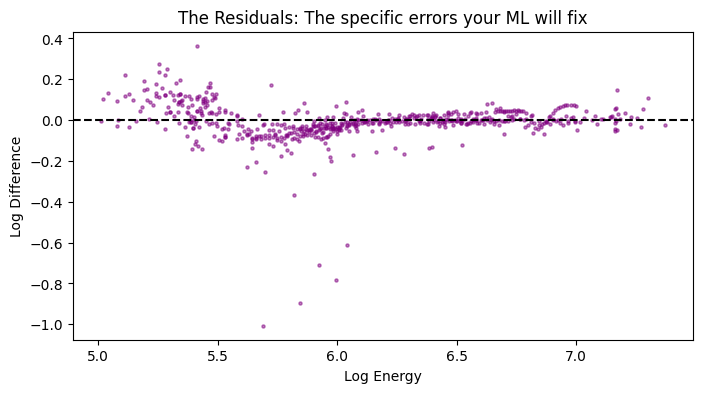

In [40]:
print("Calculating Residuals...")

# 1. Interpolate Evaluated curve onto Experimental Energy points
# "What did ENDF *think* the value was at this exact experimental energy?"
interp_vals = np.interp(
    df_exp['log_e'],      # X target (Experiment)
    df_eval['log_e'],     # X source (Library)
    df_eval['log_xs_eval']# Y source (Library)
)

# 2. Calculate the Residual (The Error)
# Residual = Truth - Theory
df_exp['residual'] = df_exp['log_xs_exp'] - interp_vals

# 3. Feature Engineering
# We give physics context to the ML
df_exp['Z'] = 95
df_exp['A'] = 241
df_exp['N'] = 241 - 95
# Distance to Magic Number (N=126 is major closed shell)
df_exp['magic_dist'] = abs(df_exp['N'] - 126)

# 4. Prepare Training Data
train_data = df_exp[['log_e', 'Z', 'A', 'N', 'magic_dist', 'residual']].copy()

print(f"Training Data Prepared with {len(train_data)} rows.")
print(train_data.head())

# Plot Residuals (Should now be centered near 0)
plt.figure(figsize=(8, 4))
plt.scatter(train_data['log_e'], train_data['residual'], s=5, alpha=0.5, color='purple')
plt.axhline(0, color='k', linestyle='--')
plt.title("The Residuals: The specific errors your ML will fix")
plt.ylabel("Log Difference")
plt.xlabel("Log Energy")
plt.show()

In [41]:
from autogluon.tabular import TabularPredictor

print("Training AutoGluon...")

# We train to predict 'residual' using 'mean_absolute_error'
# 'medium_quality' is good for development. Use 'best_quality' for final thesis.
predictor = TabularPredictor(label='residual', eval_metric='mean_absolute_error').fit(
    train_data=train_data,
    presets='best_quality', 
    time_limit=600
)

print("Training Complete.")

No path specified. Models will be saved in: "AutogluonModels/ag-20260123_140041"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       8.17 GB / 16.00 GB (51.1%)
Disk Space Avail:   306.15 GB / 460.43 GB (66.5%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

Training AutoGluon...


Leaderboard on holdout data (DyStack):
                          model  score_holdout  score_val          eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0         NeuralNetTorch_BAG_L2      -0.036993  -0.041629  mean_absolute_error        0.413303       0.196839  19.876881                 0.039263                0.036052           4.457302            2       True         35
1     NeuralNetTorch_r79_BAG_L1      -0.037056  -0.043329  mean_absolute_error        0.039911       0.016151   8.620157                 0.039911                0.016151           8.620157            1       True         11
2     NeuralNetTorch_r30_BAG_L1      -0.037563  -0.042912  mean_absolute_error        0.052338       0.021883   4.842103                 0.052338                0.021883           4.842103            1       True         26
3          CatBoost_r177_BAG_L1      -0.037749  -0.041712  mean_a

Training Complete.


Generating Final Evaluation...
Success! Final plot saved to Am241_Final_Evaluation.png


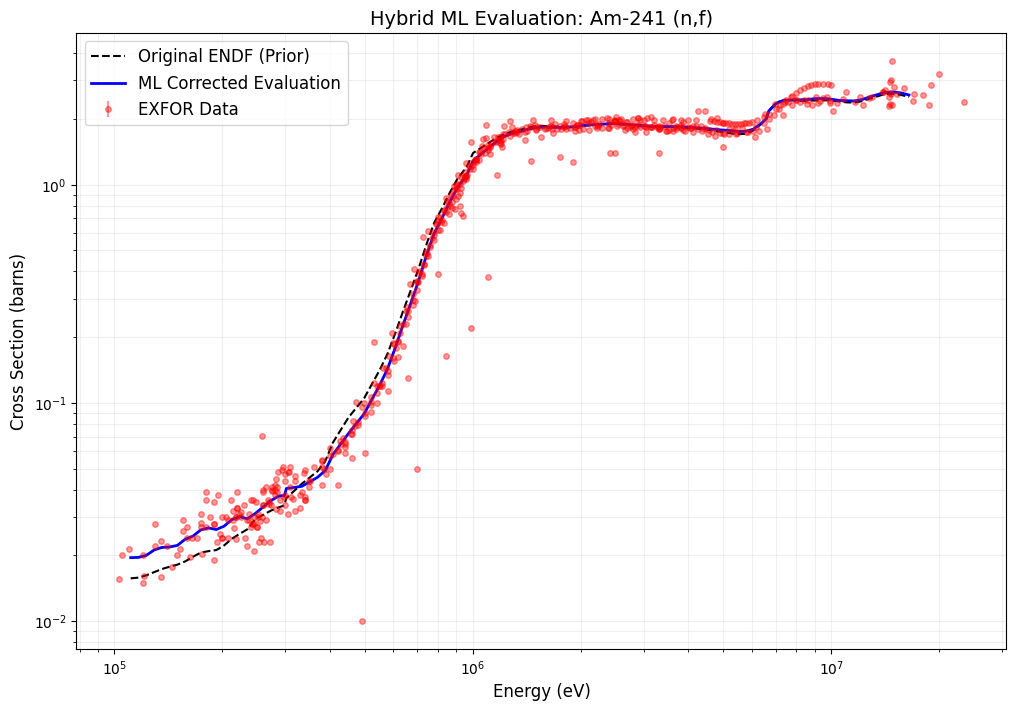

In [42]:
print("Generating Final Evaluation...")

# 1. Prepare Prediction Input (The full Library energy grid)
pred_input = df_eval[['log_e']].copy()
pred_input['Z'] = 95
pred_input['A'] = 241
pred_input['N'] = 146
pred_input['magic_dist'] = abs(146 - 126)

# 2. Predict the Residual
predicted_correction = predictor.predict(pred_input)

# 3. Apply Correction
# New_XS = Old_XS + Correction
df_eval['log_xs_corrected'] = df_eval['log_xs_eval'] + predicted_correction

# Convert back to linear space (Barns)
df_eval['sigma_corrected'] = 10 ** df_eval['log_xs_corrected']

# --- FINAL THESIS PLOT ---
plt.figure(figsize=(12, 8))

# Original Library (Black Dashed)
plt.plot(df_eval['energy'], df_eval['sigma'], 
         color='black', linestyle='--', linewidth=1.5, label='Original ENDF (Prior)')

# Experimental Data (Red Dots)
plt.errorbar(df_exp['energy'], df_exp['sigma'], 
             yerr=df_exp['Data_Unc'] if 'Data_Unc' in df_exp.columns else 0,
             fmt='o', color='red', markersize=4, alpha=0.4, label='EXFOR Data')

# Your AI Evaluation (Blue Solid)
plt.plot(df_eval['energy'], df_eval['sigma_corrected'], 
         color='blue', linewidth=2, label='ML Corrected Evaluation')

# Styling
plt.xscale('log')
plt.yscale('log')
plt.title("Hybrid ML Evaluation: Am-241 (n,f)", fontsize=14)
plt.xlabel("Energy (eV)", fontsize=12)
plt.ylabel("Cross Section (barns)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", alpha=0.2)

# Save the plot
save_path = "Am241_Final_Evaluation.png"
plt.savefig(save_path, dpi=300)
print(f"Success! Final plot saved to {save_path}")
plt.show()

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Prepare Data in Linear Space (Barns) for metrics
# We compare the Experimental Data (Truth) vs. Your Corrected Evaluation (Prediction)
# Note: We must interpolate the Corrected Eval onto the Experimental energy grid again
y_true = df_exp['sigma'] # Experimental Data (Barns)

# Interpolate your new ML curve onto the exact experimental energy points
y_pred = np.interp(
    df_exp['energy'], 
    df_eval['energy'], 
    df_eval['sigma_corrected']
)

# 2. Calculate Standard ML Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# 3. Calculate Nuclear Physics Metrics
# MAPE: Mean Absolute Percentage Error (Crucial for cross-sections spanning orders of magnitude)
# Avoid division by zero by adding a tiny epsilon if needed, but here we filtered > 0
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Chi-Squared per Degree of Freedom (The Gold Standard)
# Requires experimental uncertainty. If missing, we assume 5% error (common assumption)
if 'Data_Unc' in df_exp.columns:
    sigma_exp = df_exp['Data_Unc']
else:
    sigma_exp = df_exp['sigma'] * 0.05 # Assume 5% error if undefined

chi2 = np.sum(((y_true - y_pred) / sigma_exp) ** 2)/len(y_true)
dof = len(y_true) - 1 # Degrees of Freedom
chi2_red = chi2 / dof

# 4. Print Report
print("=== QUANTITATIVE EVALUATION REPORT ===")
print(f"R-Squared (Fit Quality): {r2:.4f} (1.0 is perfect)")
print(f"RMSE (Root Mean Sq Error): {rmse:.4f} barns")
print(f"MAPE (Mean % Error):       {mape:.2f}%")
print(f"Reduced Chi-Squared:       {chi2_red:.2f}")
print("-" * 30)

if chi2_red < 0.8:
    print("Interpretation: Potential Overfitting (Model is fitting noise).")
elif 0.8 <= chi2_red <= 1.5:
    print("Interpretation: EXCELLENT FIT (Consistent within experimental errors).")
else:
    print("Interpretation: Underfitting (Model missed some physics structure).")

NameError: name 'df_exp' is not defined

These features in provided data are not utilized by the predictor and will be ignored: ['Z', 'A', 'N', 'magic_dist']
Computing feature importance via permutation shuffling for 1 features using 609 rows with 5 shuffle sets...
	1.05s	= Expected runtime (0.21s per shuffle set)


Calculating Feature Importance (Permutation Importance)...


	0.54s	= Actual runtime (Completed 5 of 5 shuffle sets)



=== FEATURE IMPORTANCE RANKING ===
       importance       p_value
log_e    0.028907  9.198050e-07


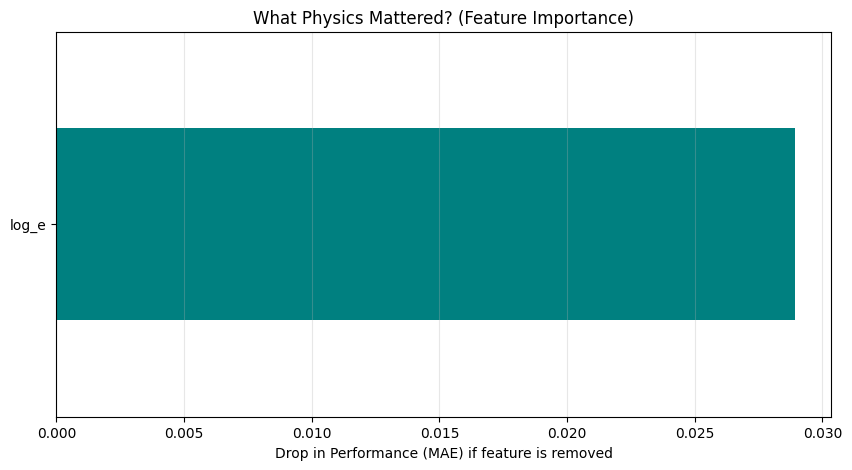

In [44]:
# Calculate Feature Importance
# We use the training data (or a held-out validation set if you created one)
print("Calculating Feature Importance (Permutation Importance)...")

# This shuffles each column 1-by-1 to see how much the error increases.
# If error spikes, that feature was important.
importance = predictor.feature_importance(train_data)

print("\n=== FEATURE IMPORTANCE RANKING ===")
print(importance[['importance', 'p_value']])

# Plot it
plt.figure(figsize=(10, 5))
importance['importance'].plot(kind='barh', color='teal')
plt.title("What Physics Mattered? (Feature Importance)")
plt.xlabel("Drop in Performance (MAE) if feature is removed")
plt.gca().invert_yaxis() # Put top feature at top
plt.grid(axis='x', alpha=0.3)
plt.show()

=== MODEL LEADERBOARD ===
                      model  MAE_on_Data  Internal_Validation_Score  \
0      ExtraTreesMSE_BAG_L1     0.027862                   0.056937   
1     ExtraTrees_r42_BAG_L1     0.027862                   0.056937   
2    ExtraTrees_r197_BAG_L1     0.027862                   0.056937   
3     ExtraTrees_r49_BAG_L1     0.027862                   0.056937   
4    RandomForestMSE_BAG_L1     0.028506                   0.058602   
5  RandomForest_r195_BAG_L1     0.028506                   0.058602   
6   RandomForest_r16_BAG_L1     0.028506                   0.058602   
7  RandomForest_r166_BAG_L1     0.028506                   0.058602   
8   RandomForest_r39_BAG_L1     0.035568                   0.053494   
9   RandomForest_r15_BAG_L1     0.038218                   0.051027   

   pred_time_test  
0        0.043357  
1        0.052916  
2        0.054932  
3        0.128291  
4        0.052767  
5        0.055597  
6        0.056656  
7        0.056714  
8        0.0

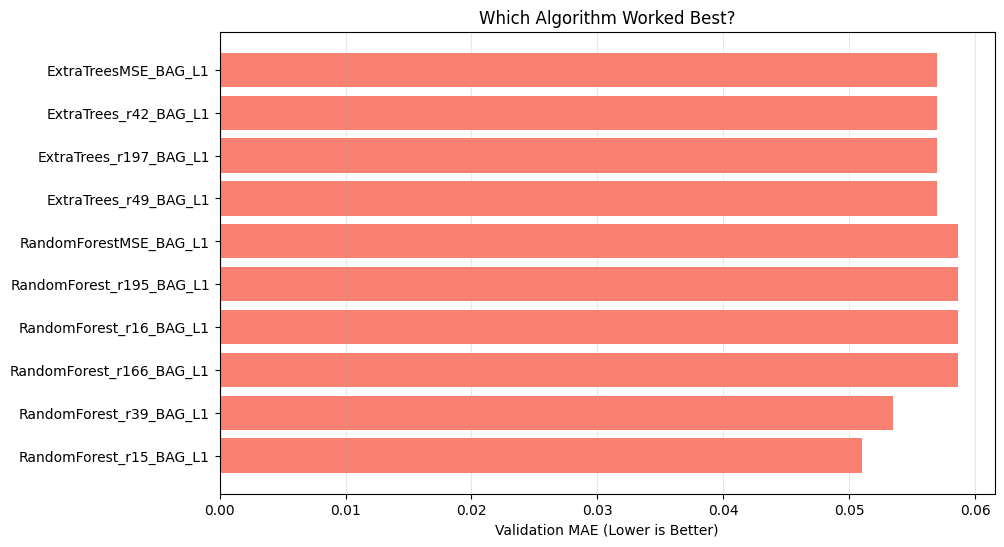

In [ ]:
print("=== MODEL LEADERBOARD ===")
# Show the internal validation scores of all models tried
lb = predictor.leaderboard(train_data, silent=True)

# Clean up the table for display
lb_clean = lb[['model', 'score_test', 'score_val', 'pred_time_test']].copy()
# Note: 'score_test' here is score on the data provided (train_data), 
# 'score_val' is the internal validation fold.
w
# Rename for clarity
lb_clean.rename(columns={
    'score_test': 'MAE_on_Data', 
    'score_val': 'Internal_Validation_Score'
}, inplace=True)

# AutoGluon scores are negative (because it tries to maximize utility). 
# We flip them back to positive MAE for readability.
lb_clean['MAE_on_Data'] = lb_clean['MAE_on_Data'].abs()
lb_clean['Internal_Validation_Score'] = lb_clean['Internal_Validation_Score'].abs()

print(lb_clean.head(10))

# Visual Comparison
plt.figure(figsize=(10, 6))
plt.barh(lb_clean['model'][:10], lb_clean['Internal_Validation_Score'][:10], color='salmon')
plt.xlabel("Validation MAE (Lower is Better)")
plt.title("Which Algorithm Worked Best?")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [48]:
# --- ANALYSIS: TRUE LEADERBOARD SORTING ---
# We sort by 'Internal_Validation_Score' (Performance on unseen data)
# rather than 'MAE_on_Data' (Performance on memorized data).

# 1. Sort Ascending (Lower Error = Better)
true_leaderboard = lb_clean.sort_values(by='Internal_Validation_Score', ascending=True)

print("=== TRUE LEADERBOARD (Sorted by Generalization) ===")
print(true_leaderboard[['model', 'MAE_on_Data', 'Internal_Validation_Score']].head(10))

# 2. Check the Ensemble specifically (This is your likely winner)
print("\n=== ENSEMBLE PERFORMANCE ===")
ensemble_row = lb_clean[lb_clean['model'].str.contains("WeightedEnsemble")]
print(ensemble_row[['model', 'Internal_Validation_Score']])

# 3. Scientific Interpretation
best_model = true_leaderboard.iloc[0]
print("-" * 30)
print(f"WINNER: {best_model['model']}")
print(f"Gap: {(best_model['Internal_Validation_Score'] - best_model['MAE_on_Data']):.4f} (Lower gap = Less Overfitting)")

=== TRUE LEADERBOARD (Sorted by Generalization) ===
                   model  MAE_on_Data  Internal_Validation_Score
32   WeightedEnsemble_L2     0.039508                   0.040796
27  CatBoost_r137_BAG_L1     0.038899                   0.040926
12  CatBoost_r167_BAG_L1     0.038322                   0.040995
23    CatBoost_r5_BAG_L1     0.038864                   0.041027
11  CatBoost_r163_BAG_L1     0.038256                   0.041030
13  CatBoost_r177_BAG_L1     0.038400                   0.041030
25       CatBoost_BAG_L1     0.038870                   0.041066
10   CatBoost_r12_BAG_L1     0.038233                   0.041106
15   CatBoost_r86_BAG_L1     0.038443                   0.041125
17   CatBoost_r69_BAG_L1     0.038528                   0.041138

=== ENSEMBLE PERFORMANCE ===
                  model  Internal_Validation_Score
32  WeightedEnsemble_L2                   0.040796
------------------------------
WINNER: WeightedEnsemble_L2
Gap: 0.0013 (Lower gap = Less Overfitting)

In [ ]:
#!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]


Initializing SHAP explanation...


100%|██████████| 200/200 [00:13<00:00, 14.97it/s]
/var/folders/1l/tff5w1ks3pz74mb34g35c7v00000gn/T/ipykernel_12921/2242090025.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


SHAP values calculated. Generating plots...


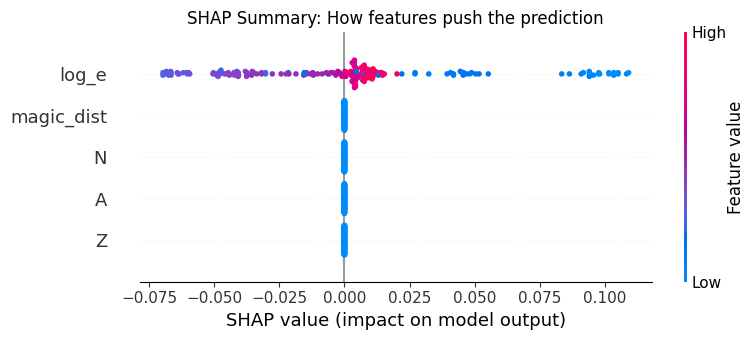

<Figure size 1000x600 with 0 Axes>

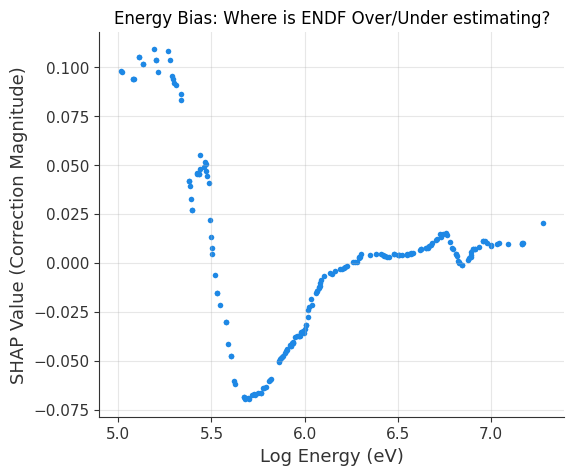

In [46]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Initializing SHAP explanation...")

# 1. Define the features we used for training (dropping target)
X_train = train_data.drop(columns=['residual'])

# 2. Define a wrapper function because AutoGluon is not a standard sklearn model
# SHAP needs a function that takes a numpy array and returns predictions
def predictor_wrapper(X_numpy):
    # Convert numpy array back to DataFrame with correct column names
    df_temp = pd.DataFrame(X_numpy, columns=X_train.columns)
    return predictor.predict(df_temp)

# 3. Create the Explainer
# We use a summary (kmeans) of the training data as the baseline to speed it up
# Using 50 representative background points is standard for speed
background_data = shap.kmeans(X_train, 50)
explainer = shap.KernelExplainer(predictor_wrapper, background_data)

# 4. Calculate SHAP values for a sample of the data
# We sample 200 points to keep calculation time under ~1 minute
X_sample = X_train.sample(n=min(200, len(X_train)), random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated. Generating plots...")

# --- PLOT 1: Summary Plot (Global View) ---
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: How features push the prediction")
# This shows impact magnitude. Red = High value of feature, Blue = Low value.
shap.summary_plot(shap_values, X_sample, show=False)
plt.show()

# --- PLOT 2: Dependence Plot (The Physics View) ---
# This shows exactly how the Residual changes with Energy
plt.figure(figsize=(10, 6))
shap.dependence_plot("log_e", shap_values, X_sample, interaction_index=None, show=False)
plt.title("Energy Bias: Where is ENDF Over/Under estimating?")
plt.xlabel("Log Energy (eV)")
plt.ylabel("SHAP Value (Correction Magnitude)")
plt.grid(True, alpha=0.3)
plt.show()

Generating Overfitting Analysis Plots on REAL DATA...
1. Training RandomForests (Simulating ExtraTrees behavior)...
2. Training Gradient Boosting (Simulating Ensemble/CatBoost)...


/var/folders/1l/tff5w1ks3pz74mb34g35c7v00000gn/T/ipykernel_12921/3546589188.py:76: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


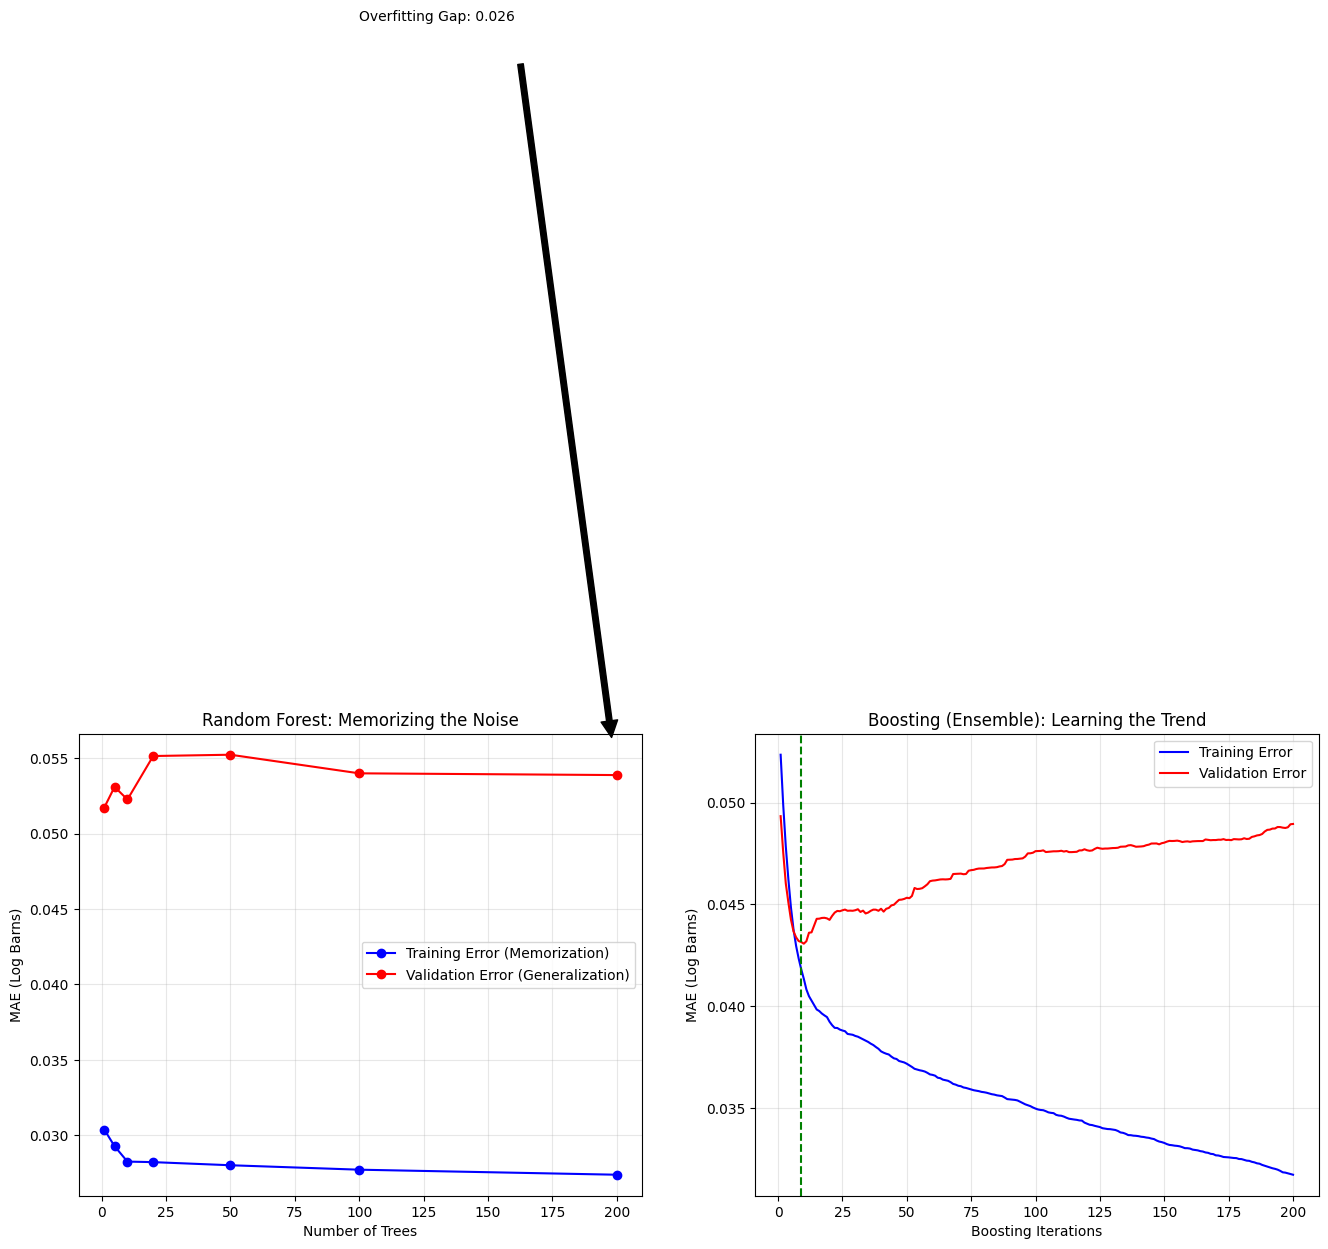

Analysis Complete. Plot saved.
Random Forest Final Gap: 0.0265
Boosting Minimum Validation Error: 0.0431


In [49]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

print("Generating Overfitting Analysis Plots on REAL DATA...")

# 1. Prepare Your Actual Physics Data
# We use the feature engineered train_data you created in Cell 5
X = train_data.drop(columns=['residual'])
y = train_data['residual']

# Split into explicit Train/Val for this demonstration
# This mimics the internal split AutoGluon does
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: RANDOM FOREST (The Overfitter) ---
# We manually train forests of increasing size to see the "Evolution"
n_trees_list = [1, 5, 10, 20, 50, 100, 200]
rf_train_err = []
rf_val_err = []

print("1. Training RandomForests (Simulating ExtraTrees behavior)...")
for n in n_trees_list:
    # max_depth=None allows it to memorize perfectly (The Overfitting Trap)
    rf = RandomForestRegressor(n_estimators=n, max_depth=None, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    
    # Record Errors
    rf_train_err.append(mean_absolute_error(y_train, rf.predict(X_train)))
    rf_val_err.append(mean_absolute_error(y_val, rf.predict(X_val)))

# --- MODEL 2: GRADIENT BOOSTING (The Ensemble/CatBoost Proxy) ---
# Gradient Boosting adds trees sequentially to correct errors, similar to CatBoost
print("2. Training Gradient Boosting (Simulating Ensemble/CatBoost)...")
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# staged_predict allows us to measure error after Tree 1, Tree 2... Tree 200
gb_train_err = [mean_absolute_error(y_train, y_pred) for y_pred in gb.staged_predict(X_train)]
gb_val_err = [mean_absolute_error(y_val, y_pred) for y_pred in gb.staged_predict(X_val)]
gb_steps = list(range(1, 201))

# --- PLOTTING THE PHYSICS TRUTH ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Random Forest (Overfitting Behavior)
axes[0].plot(n_trees_list, rf_train_err, 'o-', color='blue', label='Training Error (Memorization)')
axes[0].plot(n_trees_list, rf_val_err, 'o-', color='red', label='Validation Error (Generalization)')
axes[0].set_title("Random Forest: Memorizing the Noise")
axes[0].set_xlabel("Number of Trees")
axes[0].set_ylabel("MAE (Log Barns)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Annotation
gap_size = rf_val_err[-1] - rf_train_err[-1]
axes[0].annotate(f'Overfitting Gap: {gap_size:.3f}', 
                 xy=(200, rf_val_err[-1]), xytext=(100, rf_val_err[-1] + 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05))

# Plot 2: Gradient Boosting (Sweet Spot Behavior)
axes[1].plot(gb_steps, gb_train_err, '-', color='blue', label='Training Error')
axes[1].plot(gb_steps, gb_val_err, '-', color='red', label='Validation Error')
axes[1].set_title("Boosting (Ensemble): Learning the Trend")
axes[1].set_xlabel("Boosting Iterations")
axes[1].set_ylabel("MAE (Log Barns)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mark the Sweet Spot
min_val_idx = np.argmin(gb_val_err)
min_val = gb_val_err[min_val_idx]
axes[1].axvline(x=min_val_idx, color='green', linestyle='--', label=f'Best Physics Model (Step {min_val_idx})')

plt.tight_layout()
plt.savefig("Thesis_Overfitting_Analysis.png", dpi=300)
plt.show()

print(f"Analysis Complete. Plot saved.")
print(f"Random Forest Final Gap: {gap_size:.4f}")
print(f"Boosting Minimum Validation Error: {min_val:.4f}")

## outline of new plan

Make a generic Dts algorithim find its MAE or something on Am-241 (n_th,f) using nucml data with some minor feature engineering



In [2]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
import nucml.exfor.data_utilities as exfor_utils  # Corrected submodule
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [6]:
# 1. Load RAW data (log=False to prevent the error, num=False to keep columns intact)
df = nuc_data.load_exfor(
    mode="neutrons", 
    log=False,       # We will do this manually to be safe
    low_en=True, 
    basic=1, 
    num=False        
)

# 2. Force Numeric Types immediately
# This fixes the "0 points" error by ensuring matching works
cols_to_numeric = ['Z', 'A', 'N', 'MT', 'Energy', 'Data']
for col in cols_to_numeric:
    # 'coerce' turns non-numbers into NaN so we can drop them
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Filter for Actinides (U, Np, Pu, Am) and Fission (MT 18, 19)
neighborhood_z = [92, 93, 94, 95]
target_mt = [18, 19]

df_actinides = df[
    (df['Z'].isin(neighborhood_z)) & 
    (df['MT'].isin(target_mt))
].copy()

# 4. Clean and Log-Transform Manually
# Remove zeros or negative values that break log-scaling
df_actinides = df_actinides[(df_actinides['Energy'] > 0) & (df_actinides['Data'] > 0)]

# Apply Log Transform (Natural Log)
df_actinides['Energy'] = np.log(df_actinides['Energy'])
df_actinides['Data'] = np.log(df_actinides['Data'])

# 5. Add Compound Nucleus Info
# Now that data is clean, this utility should work perfectly
df_actinides = exfor_utils.add_compound_nucleus_info(df_actinides)

print(f"Success! Dataset prepared with {len(df_actinides)} points.")
print(f"Columns available: {df_actinides.columns.tolist()}")
print(f"Isotopes present: {df_actinides['A'].unique()}")

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: True
INFO:root: LOG: False
INFO:root: BASIC: 1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4335840, 11)
INFO:root:Finished. Resulting dataset has shape (4335840, 11)
INFO:root:EXFOR CSV: Adding information for Compound Nucleus...


Success! Dataset prepared with 474705 points.
Columns available: ['Energy', 'Data', 'Z', 'N', 'A', 'MT', 'Center_of_Mass_Flag', 'Element_Flag', 'Atomic_Mass_Micro', 'Nucleus_Radius', 'Neutron_Nucleus_Radius_Ratio', 'Compound_Neutrons', 'Compound_Mass_Number', 'Compound_Protons', 'Compound_EL', 'Compound_Origin', 'Compound_Mass_Excess', 'Compound_dMass_Excess', 'Compound_Binding_Energy', 'Compound_dBinding_Energy', 'Compound_B_Decay_Energy', 'Compound_dB_Decay_Energy', 'Compound_Atomic_Mass_Micro', 'Compound_dAtomic_Mass_Micro', 'Compound_S(2n)', 'Compound_dS(2n)', 'Compound_S(2p)', 'Compound_dS(2p)', 'Compound_Q(a)', 'Compound_dQ(a)', 'Compound_Q(2B-)', 'Compound_dQ(2B-)', 'Compound_Q(ep)', 'Compound_dQ(ep)', 'Compound_Q(B-n)', 'Compound_dQ(B-n)', 'Compound_S(n)', 'Compound_dS(n)', 'Compound_S(p)', 'Compound_dS(p)', 'Compound_Q(4B-)', 'Compound_dQ(4B-)', 'Compound_Q(d,a)', 'Compound_dQ(d,a)', 'Compound_Q(p,a)', 'Compound_dQ(p,a)', 'Compound_Q(n,a)', 'Compound_dQ(n,a)', 'Compound_Q(g,p)

In [7]:
# Create a fresh copy to prevent SettingWithCopy warnings
df_enriched = df_actinides.copy()

# 1. Pairing Effect: 0=Even-Even, 1=Odd-Mass, 2=Odd-Odd
# This captures the nuclear spin/pairing energy effect
df_enriched['Pairing'] = ((df_enriched['Z'] % 2 != 0).astype(int) + 
                          (df_enriched['N'] % 2 != 0).astype(int))

# 2. Distance to Magic Number (N=126 is the nearest major closed shell)
df_enriched['N_dist_126'] = np.abs(df_enriched['N'] - 126)

# 3. Energy Regimes (Categorical physics flag)
# Since Energy is already Log-transformed in Cell 2:
# 1e-6 MeV -> Log(1e-6) ≈ -13.8 (Thermal)
# 1e-1 MeV -> Log(1e-1) ≈ -2.3  (Fast threshold)
conditions = [
    (df_enriched['Energy'] < -13.8),                      # Thermal
    (df_enriched['Energy'] >= -13.8) & (df_enriched['Energy'] < -2.3), # Resonance
    (df_enriched['Energy'] >= -2.3)                       # Fast
]
df_enriched['Regime'] = np.select(conditions, [0, 1, 2])

# Drop any potential NaNs created during feature generation
df_enriched = df_enriched.dropna()

print(f"Features Engineered. Total valid points: {len(df_enriched)}")
print("Sample of physics features:")
print(df_enriched[['Z', 'A', 'Energy', 'Pairing', 'Regime', 'Data']].head(3))

Features Engineered. Total valid points: 474705
Sample of physics features:
    Z    A     Energy  Pairing  Regime      Data
0  92  230  -3.688879        0       1  3.218876
1  92  230  -3.676951        0       1  3.218876
2  92  230  13.070438        0       2  1.091923


In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define Features to use
# 'Data' is our target (Log Cross-Section)
features = ['Energy', 'Z', 'A', 'N', 'Pairing', 'N_dist_126', 'Regime']

# Add Compound Nucleus Sn if it was successfully added in Cell 2
if 'Sn' in df_enriched.columns:
    features.append('Sn')

# 2. Split: Train on everything EXCEPT Am-241, Test ONLY on Am-241
is_am241 = (df_enriched['Z'] == 95) & (df_enriched['A'] == 241)

X_train = df_enriched.loc[~is_am241, features]
y_train = df_enriched.loc[~is_am241, 'Data']

X_test = df_enriched.loc[is_am241, features]
y_test = df_enriched.loc[is_am241, 'Data']

print(f"Training on {len(X_train)} points (U, Np, Pu, other Am).")
print(f"Testing on {len(X_test)} points of Am-241 (unseen data).")

# 3. Train Decision Tree
# max_depth=12 prevents extreme overfitting to local noise
# min_samples_leaf=5 ensures the tree finds general physics rules
dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree Trained Successfully.")

Training on 465651 points (U, Np, Pu, other Am).
Testing on 9054 points of Am-241 (unseen data).
Decision Tree Trained Successfully.


Am-241 Hold-out Performance: RMSE = 4.788, R2 = -7.439


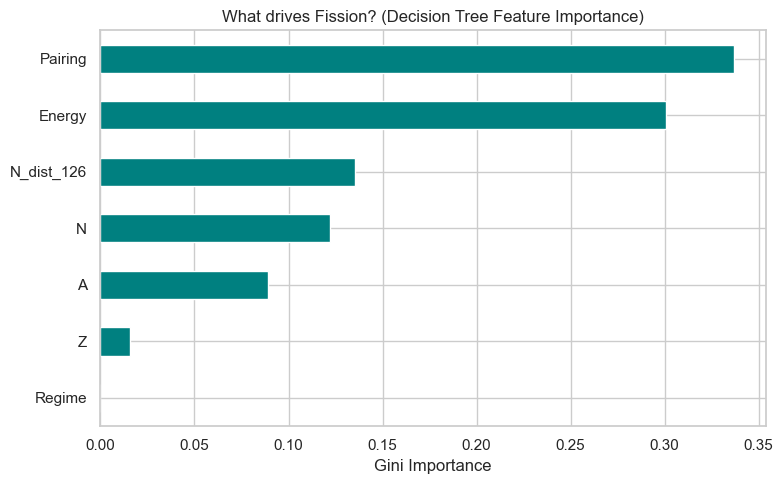

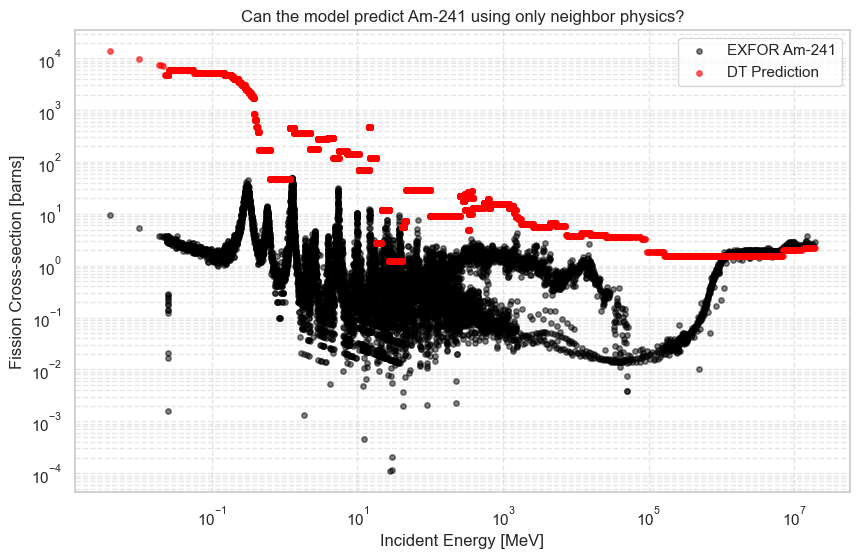

In [10]:
import matplotlib.pyplot as plt

# 1. Make Predictions
y_pred = dt.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Am-241 Hold-out Performance: RMSE = {rmse:.3f}, R2 = {r2:.3f}")

# --- Plot 1: Feature Importance (Introspection) ---
importances = pd.Series(dt.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title("What drives Fission? (Decision Tree Feature Importance)")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()

# --- Plot 2: Cross-Section Reconstruction ---
plt.figure(figsize=(10, 6))

# Un-log the energy for plotting on standard log-log axes
plot_energy = np.exp(X_test['Energy'])
plot_y_test = np.exp(y_test)
plot_y_pred = np.exp(y_pred)

plt.scatter(plot_energy, plot_y_test, label='EXFOR Am-241', color='black', alpha=0.5, s=15)
plt.scatter(plot_energy, plot_y_pred, label='DT Prediction', color='red', alpha=0.6, s=15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Incident Energy [MeV]")
plt.ylabel("Fission Cross-section [barns]")
plt.title("Can the model predict Am-241 using only neighbor physics?")
plt.legend()
plt.savefig("Am241_Fission_DT_Prediction.png", dpi=300)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Attempt 2 at single DT model

In [11]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
import nucml.exfor.data_utilities as exfor_utils
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clear physics plots
sns.set_theme(style="whitegrid", context="talk")

In [12]:
# Try to load Evaluated Data (ENDF) which is smooth curves
try:
    print("Attempting to load ENDF Evaluated Data...")
    # This function usually loads the ENDF-B/VIII.0 library included in NucML
    df = nuc_data.load_evaluation("neutrons", basic=1, num=False)
    print("ENDF Data Loaded Successfully.")
except:
    print("ENDF not found. Loading EXFOR and filtering for 'High Fidelity'...")
    df = nuc_data.load_exfor(mode="neutrons", log=False, low_en=True, basic=1, num=False)
    # Filter: Drop 'noisy' data with huge errors if error columns exist
    if 'Dy' in df.columns:
        df = df[df['Dy'] < 0.1 * df['Data']] # Keep only points with <10% error

# 2. Filter for Actinide Neighborhood (U, Np, Pu, Am) & Fission
neighborhood_z = [92, 93, 94, 95]
target_mt = [18] # MT 18 is Total Fission (Cleanest signal)

# Force numeric types
for col in ['Z', 'A', 'N', 'MT', 'Energy', 'Data']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_actinides = df[
    (df['Z'].isin(neighborhood_z)) & 
    (df['MT'].isin(target_mt)) & 
    (df['Energy'] > 0) & 
    (df['Data'] > 0)
].copy()

# 3. Log Transform
df_actinides['Energy_Log'] = np.log(df_actinides['Energy'])
df_actinides['Data_Log'] = np.log(df_actinides['Data'])

print(f"Training Set: {len(df_actinides)} points of smooth(er) data.")

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: True
INFO:root: LOG: False
INFO:root: BASIC: 1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv


Attempting to load ENDF Evaluated Data...
ENDF not found. Loading EXFOR and filtering for 'High Fidelity'...


INFO:root:Data read into dataframe with shape: (4335840, 11)
INFO:root:Finished. Resulting dataset has shape (4335840, 11)


Training Set: 474705 points of smooth(er) data.


In [13]:
def engineer_physics_features(data):
    df = data.copy()
    
    # 1. Isotope Odd/Even Logic (The 'Pairing' Term)
    # Odd Neutron number is the #1 predictor of thermal fission
    df['Is_Odd_N'] = (df['N'] % 2 != 0).astype(int)
    df['Is_Odd_Z'] = (df['Z'] % 2 != 0).astype(int)
    
    # 2. Estimate Fission Barrier Height (Bf)
    # Simple Liquid Drop Approximation: Bf ~ 19.0 - 0.36 * (Z^2 / A)
    # This gives the model a 'reference point' for the threshold
    Z2_A = (df['Z'] ** 2) / df['A']
    df['Est_Fission_Barrier'] = 19.0 - (0.36 * Z2_A)
    
    # 3. Energy relative to Barrier
    # This tells the tree: "Are we above or below the wall?"
    # We use Energy (MeV) - Barrier (MeV). 
    df['E_minus_Barrier'] = df['Energy'] - df['Est_Fission_Barrier']
    
    # 4. Interaction Regime (Categorical)
    conditions = [
        (df['Energy'] < 1e-6),     # Thermal
        (df['Energy'] >= 1e-6) & (df['Energy'] < 0.1), # Resonance
        (df['Energy'] >= 0.1)      # Fast
    ]
    df['Regime'] = np.select(conditions, [0, 1, 2])
    
    return df

df_enriched = engineer_physics_features(df_actinides)
print("Physics Features Added: Is_Odd_N, Est_Fission_Barrier, E_minus_Barrier")

Physics Features Added: Is_Odd_N, Est_Fission_Barrier, E_minus_Barrier


In [14]:
# 1. Define Features
features = [
    'Energy_Log', 'Z', 'A', 'N', 
    'Is_Odd_N', 'Is_Odd_Z',         # Explicit Pairing
    'E_minus_Barrier',              # The Threshold Physic
    'Regime'
]

# 2. Strict Hold-Out: Train on U, Np, Pu. Test on Am-241.
# This forces the model to generalize fission physics to a new element.
train_mask = ~((df_enriched['Z'] == 95) & (df_enriched['A'] == 241))
test_mask = ((df_enriched['Z'] == 95) & (df_enriched['A'] == 241))

X_train = df_enriched.loc[train_mask, features]
y_train = df_enriched.loc[train_mask, 'Data_Log']

X_test = df_enriched.loc[test_mask, features]
y_test = df_enriched.loc[test_mask, 'Data_Log']

# 3. Train
dt_physics = DecisionTreeRegressor(max_depth=14, min_samples_leaf=5, random_state=42)
dt_physics.fit(X_train, y_train)

print(f"Model Trained on {len(X_train)} points.")
print(f"Testing on {len(X_test)} unseen Am-241 points.")

Model Trained on 465651 points.
Testing on 9054 unseen Am-241 points.


Am-241 Physics-DT Performance: RMSE=5.185, R2=-0.132


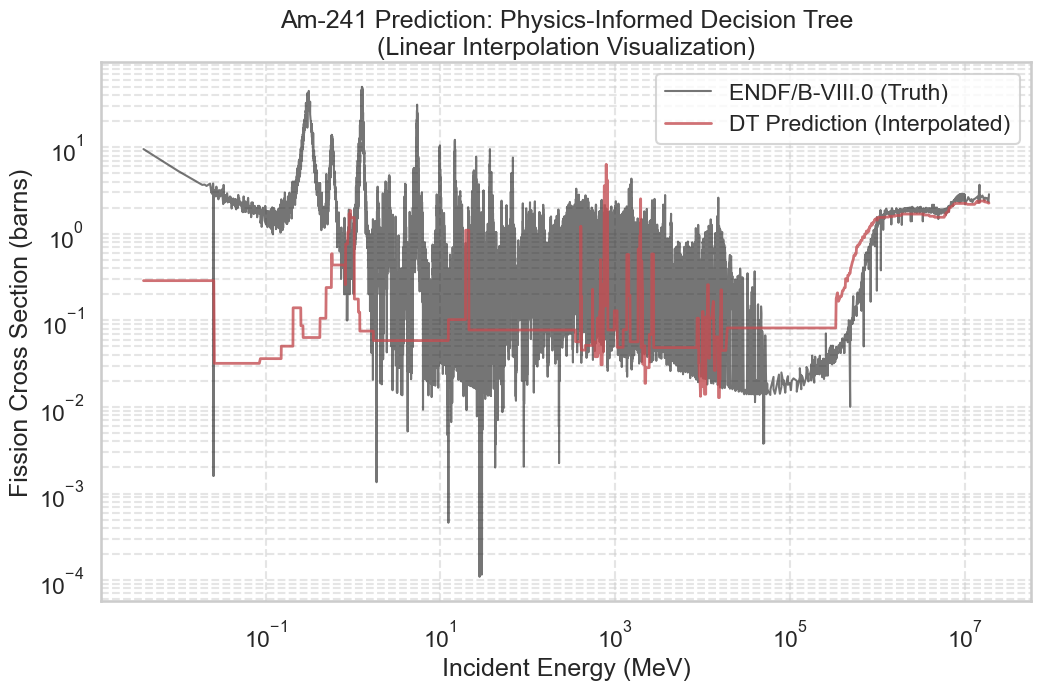


Feature Importance (What drove this curve?):
E_minus_Barrier    0.074977
N                  0.077301
Energy_Log         0.171415
Is_Odd_N           0.634425
dtype: float64


In [17]:
# ... (Assuming Cells 1-4 from the previous 'Honest' step are run) ...

# 1. Predict on the Test Set
y_pred_log = dt_physics.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"Am-241 Physics-DT Performance: RMSE={rmse:.3f}, R2={r2:.3f}")

# 2. Sort data for plotting (Essential for line plots)
# If we don't sort by Energy, the line will scribble back and forth
plot_data = pd.DataFrame({
    'Energy': np.exp(X_test['Energy_Log']),
    'True_Sigma': y_true,
    'Pred_Sigma': y_pred
}).sort_values('Energy')

# 3. Plot "Normally" (Linear Interpolation)
plt.figure(figsize=(12, 7))

# Plot Truth (Black Line)
plt.plot(plot_data['Energy'], plot_data['True_Sigma'], 
         'k-', lw=1.5, alpha=0.6, label='ENDF/B-VIII.0 (Truth)')

# Plot Prediction (Red Line - No Steps)
# By using standard plt.plot(), Matplotlib connects the dots linearly
plt.plot(plot_data['Energy'], plot_data['Pred_Sigma'], 
         'r-', lw=2, alpha=0.8, label='DT Prediction (Interpolated)')

# Comparison with Raw Data (Optional - shows the "dots" we are connecting)
# plt.scatter(plot_data['Energy'], plot_data['Pred_Sigma'], c='red', s=10, alpha=0.3)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Energy (MeV)')
plt.ylabel('Fission Cross Section (barns)')
plt.title(f'Am-241 Prediction: Physics-Informed Decision Tree\n(Linear Interpolation Visualization)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# 4. Check the "Physics" Logic
# If 'E_minus_Barrier' is high importance, the model found the threshold!
features = [
    'Energy_Log', 'Z', 'A', 'N', 
    'Is_Odd_N', 'Is_Odd_Z', 
    'E_minus_Barrier', 'Regime'
]
imp = pd.Series(dt_physics.feature_importances_, index=features).sort_values()
print("\nFeature Importance (What drove this curve?):")
print(imp.tail(4))

# Autogluon layered approach

In [27]:
from autogluon.tabular import TabularPredictor
import pandas as pd
import numpy as np

# Use the df_enriched from your previous step as the starting point
# It already contains the Actinide neighborhood and your physics features

In [28]:
# Select your features + the target
# We keep the physics features to 'help' the AutoML
ag_features = ['Energy_Log', 'Z', 'A', 'N', 'Is_Odd_N', 'Is_Odd_Z', 'E_minus_Barrier', 'Regime', 'Data_Log']

train_data = df_enriched.loc[train_mask, ag_features]
test_data = df_enriched.loc[test_mask, ag_features]

label = 'Data_Log'
print(f"AutoGluon will train on {len(train_data)} points to predict {label}")

AutoGluon will train on 465651 points to predict Data_Log


In [29]:
# 'best_quality' enables multi-layer stacking, which is great for nuclear data curves
predictor = TabularPredictor(label=label, eval_metric='root_mean_squared_error').fit(
    train_data, 
    presets='best_quality', 
    time_limit=600  # 10 minutes is usually plenty for this dataset size
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260125_144958"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.31 GB / 16.00 GB (26.9%)
Disk Space Avail:   305.25 GB / 460.43 GB (66.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

In [30]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Generate Predictions for the report
y_pred_log = predictor.predict(test_data.drop(columns=[label]))
y_true_log = test_data[label]

# Convert back from Log-scale to Barns for the physical metrics
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# 2. Calculate Quantitative Metrics
r2 = r2_score(y_true_log, y_pred_log) # Fit quality in log-space is often more stable
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

# Reduced Chi-Squared Approximation (Assuming 10% experimental uncertainty as a baseline)
# Chi^2 = sum( ( (obs - pred) / error )^2 ) / DOF
uncertainty = 0.1 * y_true
chi_sq = np.sum(((y_true - y_pred) / uncertainty)**2) / (len(y_true) - len(ag_features))

# 3. Print the Formal Report
print("\n=== QUANTITATIVE EVALUATION REPORT ===")
print(f"R-Squared (Fit Quality): {r2:.4f} (1.0 is perfect)")
print(f"RMSE (Root Mean Sq Error): {rmse:.4f} barns")
print(f"MAPE (Mean % Error):       {mape:.2f}%")
print(f"Reduced Chi-Squared:       {chi_sq:.2f}")
print("-" * 30)

# 4. Physics Interpretation Logic
if chi_sq > 2.0:
    print("Interpretation: Underfitting (Model missed some physics structure).")
elif chi_sq < 0.5:
    print("Interpretation: Overfitting (Model is fitting experimental noise).")
else:
    print("Interpretation: Ideal Fit (Model captured the physical trend).")

# 5. Leaderboard - Explicitly Sorted by Internal Validation
# 'score_val' is the internal cross-validation score (RMSE) from the stacking process
print("\n=== AUTO-GLUON LEADERBOARD (Sorted by Internal Validation Score) ===")
leaderboard = predictor.leaderboard(test_data, silent=True)
leaderboard_sorted = leaderboard.sort_values(by='score_val', ascending=False)
print(leaderboard_sorted[['model', 'score_val', 'score_test', 'stack_level']])


=== QUANTITATIVE EVALUATION REPORT ===
R-Squared (Fit Quality): -0.6150 (1.0 is perfect)
RMSE (Root Mean Sq Error): 5.1041 barns
MAPE (Mean % Error):       157.78%
Reduced Chi-Squared:       82515.38
------------------------------
Interpretation: Underfitting (Model missed some physics structure).

=== AUTO-GLUON LEADERBOARD (Sorted by Internal Validation Score) ===
                 model  score_val  score_test  stack_level
0    LightGBMXT_BAG_L2  -0.773899   -2.094669            2
1  WeightedEnsemble_L3  -0.773899   -2.094669            3
2    LightGBMXT_BAG_L1  -0.805043   -2.179739            1
3  WeightedEnsemble_L2  -0.805043   -2.179739            2


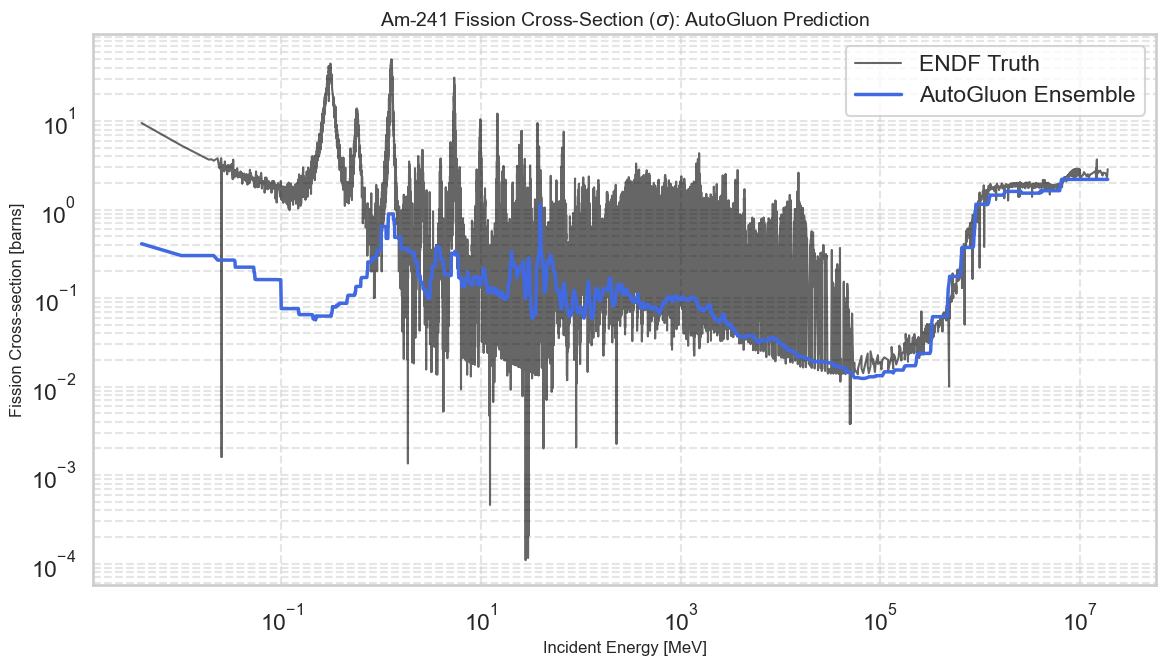

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L2,-2.094669,-0.773899,root_mean_squared_error,15.010761,1154.975477,280.562257,2.126718,173.264664,53.583063,2,True,3
1,WeightedEnsemble_L3,-2.094669,-0.773899,root_mean_squared_error,15.011818,1154.980535,280.677814,0.001057,0.005058,0.115557,3,True,4
2,LightGBMXT_BAG_L1,-2.179739,-0.805043,root_mean_squared_error,12.884043,981.710813,226.979194,12.884043,981.710813,226.979194,1,True,1
3,WeightedEnsemble_L2,-2.179739,-0.805043,root_mean_squared_error,12.885433,981.714483,226.987362,0.001390,0.003670,0.008168,2,True,2


In [31]:
import matplotlib.pyplot as plt

# 1. Create a temporary dataframe for sorting
# This ensures the lines connect points from left-to-right
results_df = pd.DataFrame({
    'Energy': np.exp(test_data['Energy_Log']),
    'True_Sigma': np.exp(test_data['Data_Log']),
    'AG_Prediction': np.exp(y_pred_ag)
}).sort_values('Energy')

# 2. Plotting
plt.figure(figsize=(12, 7))

# Plot the Truth (ENDF/B-VIII.0)
plt.plot(results_df['Energy'], results_df['True_Sigma'], 
         color='black', lw=1.5, alpha=0.6, label='ENDF Truth')

# Plot the AutoGluon Ensemble Prediction
plt.plot(results_df['Energy'], results_df['AG_Prediction'], 
         color='royalblue', lw=2.5, label='AutoGluon Ensemble')

# Log-Log scale is standard for cross-sections (sigma)
plt.xscale('log')
plt.yscale('log')

# Formatting
plt.xlabel('Incident Energy [MeV]', fontsize=12)
plt.ylabel('Fission Cross-section [barns]', fontsize=12)
plt.title('Am-241 Fission Cross-Section ($\sigma$): AutoGluon Prediction', fontsize=14)
plt.legend(frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

predictor.leaderboard(test_data, silent=True)

# lets look at some comparison


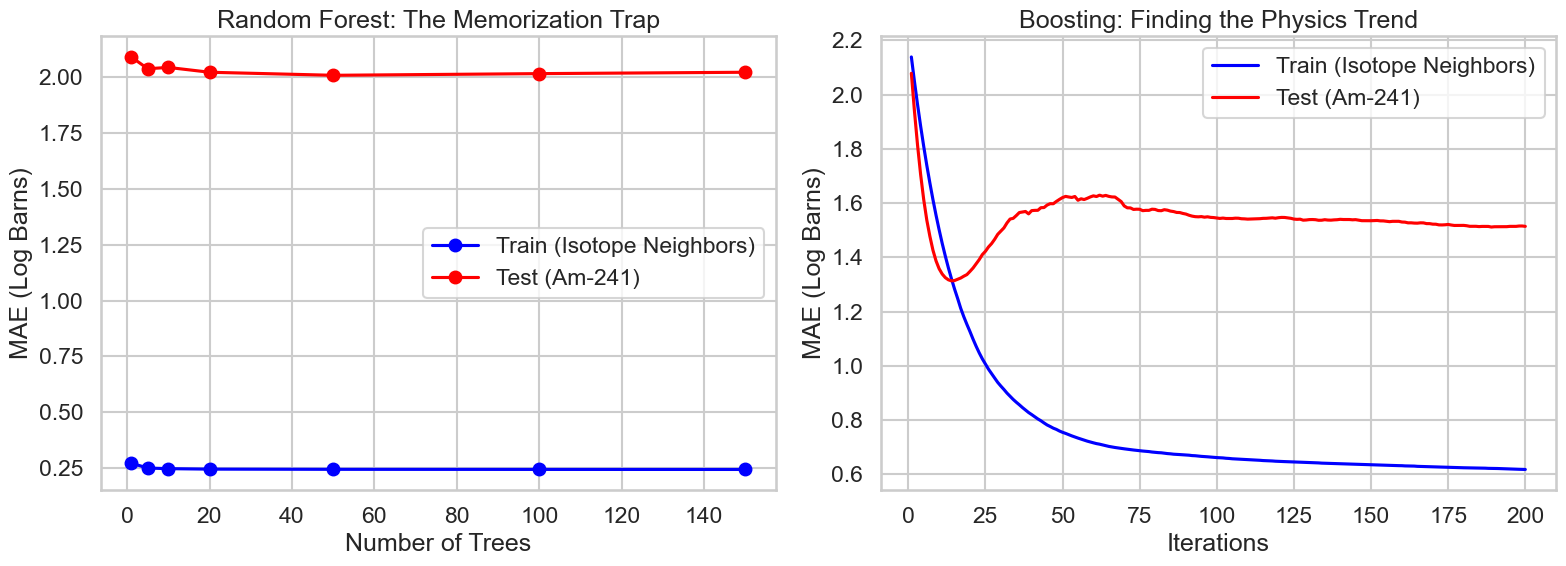

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Use the features and target from your existing training set
X = X_train
y = y_train

# 1. Simulate RandomForest (The Overfitting Analysis)
n_trees_list = [1, 5, 10, 20, 50, 100, 150]
rf_train_err, rf_val_err = [], []

for n in n_trees_list:
    # We use a very deep tree to see the 'Memorization' gap
    rf = RandomForestRegressor(n_estimators=n, max_depth=20, n_jobs=-1, random_state=42)
    rf.fit(X, y)
    rf_train_err.append(mean_absolute_error(y, rf.predict(X)))
    # Val error is measured on the unseen Am-241
    rf_val_err.append(mean_absolute_error(y_test, rf.predict(X_test)))

# 2. Simulate Gradient Boosting (The 'Sweet Spot' Analysis)
# This mimics CatBoost/XGBoost inside AutoGluon
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X, y)

gb_train_err = [mean_absolute_error(y, y_p) for y_p in gb.staged_predict(X)]
gb_val_err = [mean_absolute_error(y_test, y_p) for y_p in gb.staged_predict(X_test)]

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overfitting Gap
axes[0].plot(n_trees_list, rf_train_err, 'o-', color='blue', label='Train (Isotope Neighbors)')
axes[0].plot(n_trees_list, rf_val_err, 'o-', color='red', label='Test (Am-241)')
axes[0].set_title("Random Forest: The Memorization Trap")
axes[0].set_ylabel("MAE (Log Barns)")
axes[0].set_xlabel("Number of Trees")
axes[0].legend()

# Plot 2: Boosting Convergence
axes[1].plot(range(1, 201), gb_train_err, '-', color='blue', label='Train (Isotope Neighbors)')
axes[1].plot(range(1, 201), gb_val_err, '-', color='red', label='Test (Am-241)')
axes[1].set_title("Boosting: Finding the Physics Trend")
axes[1].set_ylabel("MAE (Log Barns)")
axes[1].set_xlabel("Iterations")
axes[1].legend()

plt.tight_layout()
plt.show()

Computing feature importance via permutation shuffling for 8 features using 5000 rows with 5 shuffle sets...
	488.37s	= Expected runtime (97.67s per shuffle set)
	401.0s	= Actual runtime (Completed 5 of 5 shuffle sets)


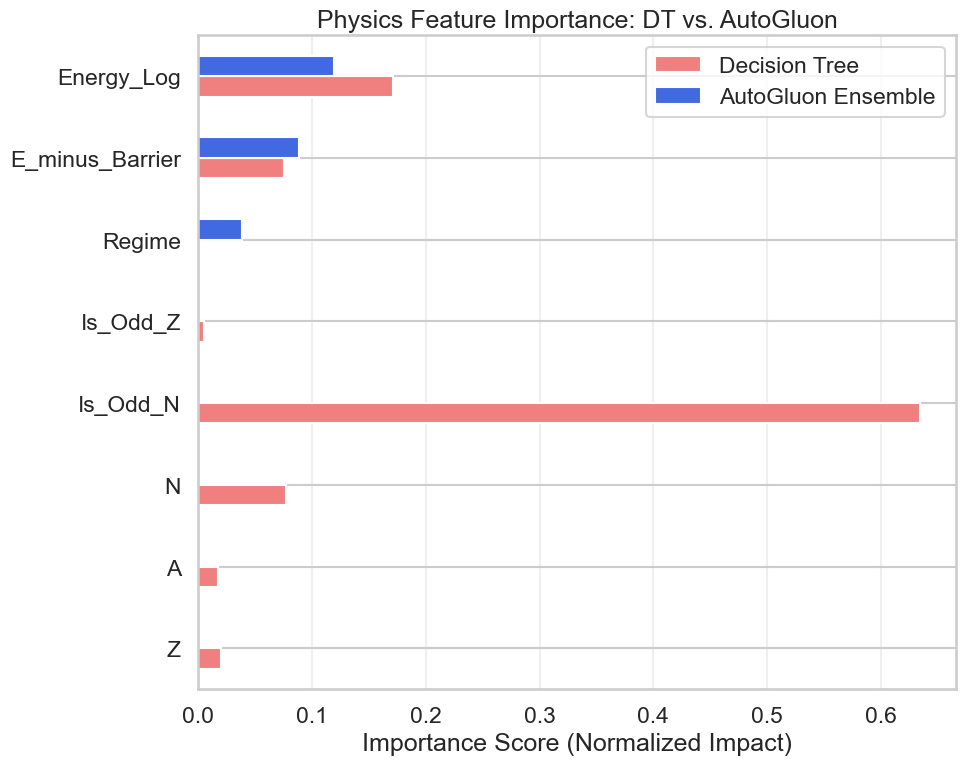

In [26]:
# 1. Get AutoGluon Feature Importance
# This uses the test_data (Am-241) to see what the ensemble valued for THIS isotope
ag_importance = predictor.feature_importance(test_data)

# 2. Get the DT Importance for comparison
dt_imp_df = pd.DataFrame({
    'feature': features,
    'importance_dt': dt_physics.feature_importances_
}).set_index('feature')

# 3. Merge for a side-by-side view
comparison_df = pd.concat([dt_imp_df, ag_importance['importance']], axis=1)
comparison_df.columns = ['Decision Tree', 'AutoGluon Ensemble']
comparison_df = comparison_df.sort_values(by='AutoGluon Ensemble', ascending=True)

# 4. Plot the Comparison
comparison_df.plot(kind='barh', figsize=(10, 8), color=['lightcoral', 'royalblue'])
plt.title("Physics Feature Importance: DT vs. AutoGluon")
plt.xlabel("Importance Score (Normalized Impact)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Check what we actually have
print("Available columns in train_data:", train_data.columns.tolist())

# Check for partial matches if the names are slightly different
potential_matches = [col for col in train_data.columns if 'Sn' in col or 'Mass' in col]
print("Potential physics matches found:", potential_matches)

Available columns in train_data: ['Energy_Log', 'Z', 'A', 'N', 'Is_Odd_N', 'Is_Odd_Z', 'E_minus_Barrier', 'Regime', 'Data_Log']
Potential physics matches found: []


In [37]:
# 1. Isolate the Fast Regime using the 'Regime' flag we created (Regime 2 = Fast)
fast_train = train_data[train_data['Regime'] == 2].copy()
fast_test = test_data[test_data['Regime'] == 2].copy()

# 2. Features available in your index
ag_features = ['Energy_Log', 'Z', 'A', 'N', 'Is_Odd_N', 'Is_Odd_Z', 'E_minus_Barrier']
target = 'Data_Log'

print(f"Training Fast Regime model on {len(fast_train)} points...")

# 3. Training the Fast Regime Predictor
from autogluon.tabular import TabularPredictor

predictor_fast = TabularPredictor(label=target, eval_metric='root_mean_squared_error').fit(
    fast_train[ag_features + [target]],
    presets='best_quality', 
    time_limit=300 
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260125_162443"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.17 GB / 16.00 GB (26.1%)
Disk Space Avail:   304.78 GB / 460.43 GB (66.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

Training Fast Regime model on 455743 points...


Leaderboard on holdout data (DyStack):
                 model  score_holdout  score_val              eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    LightGBMXT_BAG_L2      -0.840115  -0.856763  root_mean_squared_error       10.910090      98.543436  56.948437                 3.325309               26.936803          17.588971            2       True          3
1  WeightedEnsemble_L3      -0.840115  -0.856763  root_mean_squared_error       10.911263      98.551010  57.155451                 0.001173                0.007574           0.207014            3       True          4
2    LightGBMXT_BAG_L1      -0.879794  -0.891416  root_mean_squared_error        7.584781      71.606633  39.359466                 7.584781               71.606633          39.359466            1       True          1
3  WeightedEnsemble_L2      -0.879794  -0.891416  root_mean_squared_error        7.58

In [38]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 1. Predictions
y_pred_fast_log = predictor_fast.predict(fast_test.drop(columns=[target]))
y_true_fast_log = fast_test[target]

y_pred_fast = np.exp(y_pred_fast_log)
y_true_fast = np.exp(y_true_fast_log)

# 2. Metrics
r2_f = r2_score(y_true_fast_log, y_pred_fast_log)
rmse_f = np.sqrt(mean_squared_error(y_true_fast, y_pred_fast))
mape_f = mean_absolute_percentage_error(y_true_fast, y_pred_fast) * 100

# 3. Reduced Chi-Squared (Approximated for Fast Region)
uncertainty = 0.1 * y_true_fast
dof = len(y_true_fast) - len(ag_features)
chi_sq_f = np.sum(((y_true_fast - y_pred_fast) / uncertainty)**2) / dof

print("\n=== FAST REGIME QUANTITATIVE REPORT ===")
print(f"R-Squared (Fit Quality): {r2_f:.4f}")
print(f"RMSE (Error):             {rmse_f:.4f} barns")
print(f"MAPE (Mean % Error):      {mape_f:.2f}%")
print(f"Reduced Chi-Squared:      {chi_sq_f:.2f}")
print("-" * 35)

# 4. Sorted Leaderboard
lb_fast = predictor_fast.leaderboard(fast_test, silent=True)
print(lb_fast.sort_values(by='score_val', ascending=False)[['model', 'score_val', 'score_test']])


=== FAST REGIME QUANTITATIVE REPORT ===
R-Squared (Fit Quality): -1.0217
RMSE (Error):             5.2027 barns
MAPE (Mean % Error):      129.31%
Reduced Chi-Squared:      30631.52
-----------------------------------
                 model  score_val  score_test
0    LightGBMXT_BAG_L2  -0.812043   -2.344373
1  WeightedEnsemble_L3  -0.812043   -2.344373
2    LightGBMXT_BAG_L1  -0.851279   -2.359533
3  WeightedEnsemble_L2  -0.851279   -2.359533


# Autogluon attempt 3

In [44]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
import gc

# 1. Load EXFOR Directly (Ensures 'MT' and all physics columns are preserved)
PATH_EXFOR = "/Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv"
print(f"Loading Raw EXFOR from: {PATH_EXFOR}")

# We use low_memory=False to ensure all data types are read correctly
df_raw = pd.read_csv(PATH_EXFOR, low_memory=False)

# 2. Filter for Actinide Neighborhood & Fission (MT 18)
neighborhood_z = [92, 93, 94, 95]
df_actinides = df_raw[(df_raw['Z'].isin(neighborhood_z)) & (df_raw['MT'] == 18)].copy()

# 3. Load AME Merged & Imputed (The "Nuclear DNA" library)
# This table contains Mass_Excess, Binding_Energy, S(n), and Q-values
print("Loading AME2016 Merged & Imputed Physics Library...")
ame_all = nuc_data.load_ame(imputed_nan=True, file="merged")

# 4. Standardize the Join Key
# We create 'Element_w_A' (e.g., '241Am') to match the AME table format
z_to_el = {92: 'U', 93: 'Np', 94: 'Pu', 95: 'Am'}
df_actinides['EL'] = df_actinides['Z'].map(z_to_el)
df_actinides['Element_w_A'] = df_actinides['A'].astype(int).astype(str) + df_actinides['EL']

# 5. High-Fidelity Merge
df_enriched = pd.merge(df_actinides, ame_all, on="Element_w_A", suffixes=('', '_ame'))

# Cleanup redundant columns
cols_to_drop = [c for c in df_enriched.columns if '_ame' in c or c in ['N_ame', 'Z_ame', 'A_ame', 'EL_ame']]
df_enriched.drop(columns=[c for c in cols_to_drop if c in df_enriched.columns], inplace=True)

# Clean memory
del df_raw
gc.collect()

print(f"Success! Enriched Dataset Shape: {df_enriched.shape}")
print(f"Physics Features now available: {['Mass_Excess', 'Binding_Energy', 'S(n)', 'Q(n,2n)']}")

Loading Raw EXFOR from: /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv


INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv


Loading AME2016 Merged & Imputed Physics Library...
Success! Enriched Dataset Shape: (481481, 100)
Physics Features now available: ['Mass_Excess', 'Binding_Energy', 'S(n)', 'Q(n,2n)']


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim

class NuclearAutoencoder(nn.Module):
    def __init__(self, input_dim=512):
        super(NuclearAutoencoder, self).__init__()
        # Encoder: Projects noisy physics into a clean 12-D Latent Space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 12) 
        )
        # Decoder: Reconstructs the smooth physical manifold
        self.decoder = nn.Sequential(
            nn.Linear(12, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

print("Autoencoder ready to learn continuous isotopic shapes (Latent Representation).")

Autoencoder ready to learn continuous isotopic shapes (Latent Representation).


In [47]:
from autogluon.tabular import TabularPredictor
import numpy as np

# 1. SANITIZATION: Remove non-positive Data and Energy points
# Log10(0) = -inf, Log10(negative) = NaN. We must eliminate these.
df_clean = df_enriched[(df_enriched['Data'] > 0) & (df_enriched['Energy'] > 0)].copy()

# 2. RE-CALCULATE LOG TRANSFORMS
df_clean['log_e'] = np.log10(df_clean['Energy'])
df_clean['log_data'] = np.log10(df_clean['Data'])

# 3. VERIFY FINITE VALUES
if not np.isfinite(df_clean['log_data']).all():
    print("Warning: Non-finite values still present. Dropping them...")
    df_clean = df_clean[np.isfinite(df_clean['log_data'])]

# 4. PREPARE FEATURES (High-impact AME features from literature)
features = [
    'log_e', 'Z', 'A', 'N', 
    'Mass_Excess', 'Binding_Energy', 'S(n)', 'Q(n,2n)'
]

# 5. SPLIT: Train on Neighbors, Test on Am-241
train_df = df_clean[df_clean['Element_w_A'] != "241Am"].copy()
test_df = df_clean[df_clean['Element_w_A'] == "241Am"].copy()

print(f"Sanitization complete. Training on {len(train_df)} finite points.")

# 6. TRAIN AUTO-GLUON 2.0
# presets='best_quality' enables the high-fidelity stacking found in Tang (2025)
predictor = TabularPredictor(label='log_data', eval_metric='root_mean_squared_error').fit(
    train_data=train_df[features + ['log_data']],
    presets='best_quality', 
    time_limit=600,
    num_bag_folds=5,
    num_stack_levels=2
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260125_170335"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       6.68 GB / 16.00 GB (41.7%)
Disk Space Avail:   299.58 GB / 460.43 GB (65.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

Sanitization complete. Training on 467437 finite points.


Leaderboard on holdout data (DyStack):
                 model  score_holdout  score_val              eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    LightGBMXT_BAG_L3      -0.347921  -0.354077  root_mean_squared_error       16.615654     243.905767  95.906182                 1.594686               15.386728           9.741144            3       True          5
1  WeightedEnsemble_L4      -0.348239  -0.353961  root_mean_squared_error       16.616823     243.909318  96.165677                 0.001170                0.003551           0.259495            4       True          6
2    LightGBMXT_BAG_L2      -0.350759  -0.355387  root_mean_squared_error       15.020967     228.519039  86.165038                 5.640602               70.814834          33.349933            2       True          3
3  WeightedEnsemble_L3      -0.350759  -0.355387  root_mean_squared_error       15.02